In [3]:
import pandas as pd
import glob
import os
from datetime import datetime

input_folder = r'C:/Users/HEMAL/Downloads/Kitoko Data'
output_file = 'Kitoko_Campaign_Data.xlsx'

all_files = glob.glob(os.path.join(input_folder, "*.csv"))

print(f"Found {len(all_files)} files:", all_files)

dfs = []

for file in all_files:
    base_name = os.path.basename(file)
    name_without_ext = os.path.splitext(base_name)[0]

    try:
        report_date = datetime.strptime(name_without_ext, "%d %b %Y").date()
    except ValueError:
        try:
            report_date = datetime.strptime(name_without_ext, "%d %B %Y").date()
        except ValueError:
            print(f"⚠️ Skipping file '{file}' due to incorrect filename format.")
            continue

    df = pd.read_csv(file)
    df['Report Date'] = report_date

    df['Report Date'] = pd.to_datetime(df['Report Date'])
    df['Report Date'] = df['Report Date'].dt.strftime('%d %b %Y')

    cols = ['Report Date'] + [col for col in df.columns if col != 'Report Date']
    df = df[cols]

    dfs.append(df)

if dfs:
    final_df = pd.concat(dfs, ignore_index=True)

    # Convert for sorting
    final_df['Report Date'] = pd.to_datetime(final_df['Report Date'], format='%d %b %Y')

    # Sort newest first
    final_df = final_df.sort_values(by='Report Date', ascending=False)

    # Convert back to string format for Excel
    final_df['Report Date'] = final_df['Report Date'].dt.strftime('%d %b %Y')

    if os.path.exists(output_file):
        os.remove(output_file)
        print(f"🗑️ Existing file '{output_file}' has been deleted.")

    final_df.to_excel(output_file, index=False)
    print(f"✅ Successfully merged {len(all_files)} files and saved to '{output_file}'!")
else:
    print("❌ No files were merged. Please check your folder and file names.")


Found 104 files: ['C:/Users/HEMAL/Downloads/Kitoko Data\\01 apr 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\01 feb 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\01 mar 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\01 may 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\02 apr 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\02 feb 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\02 mar 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\02 may 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\03 apr 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\03 feb 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\03 mar 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\03 may 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\04 apr 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\04 feb 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\04 mar 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\04 may 2025.csv', 'C:/Users/HEMAL/Downloads/Kitoko Data\\05 apr 2025.csv', 'C:/Users/HEM

In [6]:
import pandas as pd
import datetime as dt
from openpyxl import load_workbook

# File path
file_path = r'C:/Users/HEMAL/Downloads/Kitoko Data/Kitoko order details.xlsx'

# Load the data
try:
    df = pd.read_excel(file_path, sheet_name='Order Details')
except Exception as e:
    print(f"Error loading Excel file: {e}")
    exit()

# Check the loaded columns
print("Loaded columns:", df.columns)

# Extract first 10 characters of purchase-date and convert to datetime
if 'purchase-date' in df.columns:
    df['purchase-date'] = df['purchase-date'].astype(str).str[:10]
    df['purchase-date'] = pd.to_datetime(df['purchase-date'], format='%Y-%m-%d', errors='coerce')
else:
    print("Column 'purchase-date' not found!")
    exit()

# Convert quantity to numeric
if 'quantity' in df.columns:
    df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').fillna(0).astype(int)
else:
    df['quantity'] = 1

# Convert item-price to numeric
if 'item-price' in df.columns:
    df['item-price'] = pd.to_numeric(df['item-price'], errors='coerce').fillna(0)
else:
    print("Column 'item-price' not found!")
    exit()

# Calculate total order value
df['total_value'] = df['item-price']

# Drop empty ASINs
if 'asin' not in df.columns:
    print("Column 'asin' not found!")
    exit()
df = df[df['asin'].notna()]

# Group by ASIN (product-level)
reference_date = pd.Timestamp('2025-05-15')
rfm_df = df.groupby('asin').agg({
    # 'purchase-date': lambda x: (pd.Timestamp.today() - x.max()).days,  # Recency
    'purchase-date': lambda x: (reference_date - x.max()).days,  # Recency
    'asin': 'count',                                                   # Frequency
    'total_value': 'sum'                                               # Monetary
}).rename(columns={
    'purchase-date': 'Recency',
    'asin': 'Frequency',
    'total_value': 'Monetary'
}).reset_index()

# Rank into RFM scores (1-5)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5,4,3,2,1])
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1,2,3,4,5])

# Final RFM Score
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Optional: Sort by Monetary
rfm_df = rfm_df.sort_values(by='Monetary', ascending=False)

print(rfm_df.head())

# Save to same Excel file, new sheet (replace if exists)
output_path = file_path
sheet_name = 'RFM_Scores'

try:
    # Load the existing workbook
    book = load_workbook(output_path)
    
    # If sheet exists, remove it
    if sheet_name in book.sheetnames:
        std = book[sheet_name]
        book.remove(std)
        book.save(output_path)
    
    # Use ExcelWriter to append new sheet
    with pd.ExcelWriter(output_path, engine='openpyxl', mode='a') as writer:
        rfm_df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    print(f"✅ RFM data saved to sheet '{sheet_name}' in {output_path}")
except Exception as e:
    print(f"❌ Error saving Excel file: {e}")


Loaded columns: Index(['amazon-order-id', 'merchant-order-id', 'purchase-date',
       'last-updated-date', 'order-status', 'fulfillment-channel',
       'sales-channel', 'order-channel', 'url', 'ship-service-level',
       'product-name', 'sku', 'asin', 'item-status', 'quantity', 'currency',
       'item-price', 'item-tax', 'shipping-price', 'shipping-tax',
       'item-promotion-discount', 'ship-promotion-discount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'is-business-order', 'purchase-order-number'],
      dtype='object')
           asin  Recency  Frequency   Monetary R_Score F_Score M_Score  \
6    B0CZ97WPWL        0       2027  511835.80       5       5       5   
26   B0CZ9HRMLW        1        313  109257.85       5       5       5   
103  B0DJ3397M1        1        164   47623.00       5       5       5   
104  B0DJ33RR1F        2        168   40825.00       5       5       5   
18   B0CZ9BR84P        9         97   34534.5

In [ ]:
import pandas as pd
import datetime as dt
from openpyxl import load_workbook

# File path
file_path = r'C:/Users/HEMAL/Downloads/Kitoko Data/Kitoko order details.xlsx'
sheet_input = 'Order Details'
sheet_output = 'RFM_Scores_new'

# Load the data
try:
    df = pd.read_excel(file_path, sheet_name=sheet_input)
    print(f"✅ Loaded data from sheet '{sheet_input}'")
except Exception as e:
    print(f"❌ Error loading Excel file: {e}")
    exit()

# Check and parse purchase-date
if 'purchase-date' not in df.columns:
    print("❌ Column 'purchase-date' not found!")
    exit()

df['purchase-date'] = pd.to_datetime(df['purchase-date'].astype(str).str[:10], errors='coerce')

# Handle missing/invalid dates
df = df.dropna(subset=['purchase-date'])

# Quantity and price cleanup
df['quantity'] = pd.to_numeric(df.get('quantity', 1), errors='coerce').fillna(1).astype(int)

if 'item-price' not in df.columns:
    print("❌ Column 'item-price' not found!")
    exit()

df['item-price'] = pd.to_numeric(df['item-price'], errors='coerce').fillna(0)

# Compute total_value
df['total_value'] = df['item-price']

# Filter out missing ASINs
if 'asin' not in df.columns:
    print("❌ Column 'asin' not found!")
    exit()
df = df[df['asin'].notna()]

# Group by product (ASIN) and compute RFM
today = pd.Timestamp.today()

reference_date = pd.Timestamp('2025-05-15')
rfm_df = df.groupby('asin').agg({
    # 'purchase-date': lambda x: (today - x.max()).days,   # Recency
    'purchase-date': lambda x: (reference_date - x.max()).days,  # Recency
    'asin': 'count',                                     # Frequency
    'total_value': 'sum'                                 # Monetary
}).rename(columns={
    'purchase-date': 'Recency',
    'asin': 'Frequency',
    'total_value': 'Monetary'
}).reset_index()

# Assign RFM Scores (1 = worst, 5 = best)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Concatenate RFM Score
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Optional: Assign simple segment labels (can be expanded later)
def segment_label(score):
    if score == '555':
        return 'Top Performer'
    elif score.startswith('5'):
        return 'Recent Favorite'
    elif score.endswith('5'):
        return 'High Value'
    elif score.startswith('1'):
        return 'At Risk'
    else:
        return 'Mid Performer'

rfm_df['Segment'] = rfm_df['RFM_Score'].apply(segment_label)

# Sort by Monetary value
rfm_df = rfm_df.sort_values(by='Monetary', ascending=False)

# Display top rows
print(rfm_df.head())

# Save results to new Excel sheet
try:
    book = load_workbook(file_path)
    if sheet_output in book.sheetnames:
        del book[sheet_output]
        book.save(file_path)

    with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
        rfm_df.to_excel(writer, sheet_name=sheet_output, index=False)

    print(f"✅ RFM analysis saved to sheet '{sheet_output}' in: {file_path}")
except Exception as e:
    print(f"❌ Error saving Excel file: {e}")


✅ Loaded data from sheet 'Order Details'
           asin  Recency  Frequency   Monetary R_Score F_Score M_Score  \
6    B0CZ97WPWL        0       2027  511835.80       5       5       5   
26   B0CZ9HRMLW        1        313  109257.85       5       5       5   
103  B0DJ3397M1        1        164   47623.00       5       5       5   
104  B0DJ33RR1F        2        168   40825.00       5       5       5   
18   B0CZ9BR84P        9         97   34534.54       4       5       5   

    RFM_Score        Segment  
6         555  Top Performer  
26        555  Top Performer  
103       555  Top Performer  
104       555  Top Performer  
18        455     High Value  
✅ RFM analysis saved to sheet 'RFM_Scores_new' in: C:/Users/HEMAL/Downloads/Kitoko Data/Kitoko order details.xlsx


In [7]:
%pip install statsmodels.tsa.arima.model 

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement statsmodels.tsa.arima.model (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for statsmodels.tsa.arima.model


✅ Sales Data loaded successfully
        Date  Total Sales  Total Order Items  Ad Spent  Ad Sales  Ad Orders  \
0 2025-04-30       3364.0                 13   1176.32   1288.41          6   
1 2025-04-29      12280.0                 42   1051.15   1352.67          6   
2 2025-04-28       6828.0                 22   1002.07   1895.54          7   
3 2025-04-27       7711.0                 27   1203.32   1608.90          8   
4 2025-04-26       8204.0                 28   1143.20   3492.86         11   

   ROAS   ACOS  TACOS  Impressions  Clicks    CPC  Total Sessions  Page Views  \
0  1.10  91.30  34.97        31598     108  11.93             252         370   
1  1.29  77.71   8.56        27864      89  15.20             333         440   
2  1.89  52.86  14.68        21482      91  20.83             300         399   
3  1.34  74.79  15.61        38503     106  15.18             229         286   
4  3.06  32.73  13.93        55484      99  35.28             283         384   

   Sp

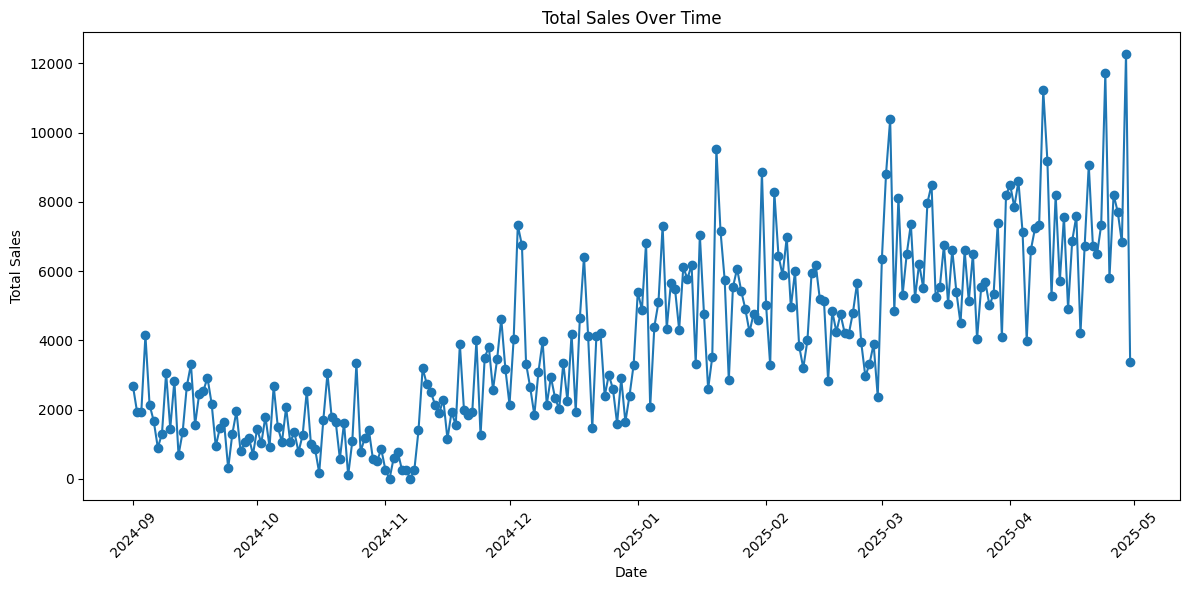

c:\Users\HEMAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HEMAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HEMAL\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


📈 Next 7 days forecast:
2025-05-01    7053.940976
2025-05-02    7344.945705
2025-05-03    7367.895598
2025-05-04    7369.705526
2025-05-05    7369.848265
2025-05-06    7369.859522
2025-05-07    7369.860410
Freq: D, Name: predicted_mean, dtype: float64


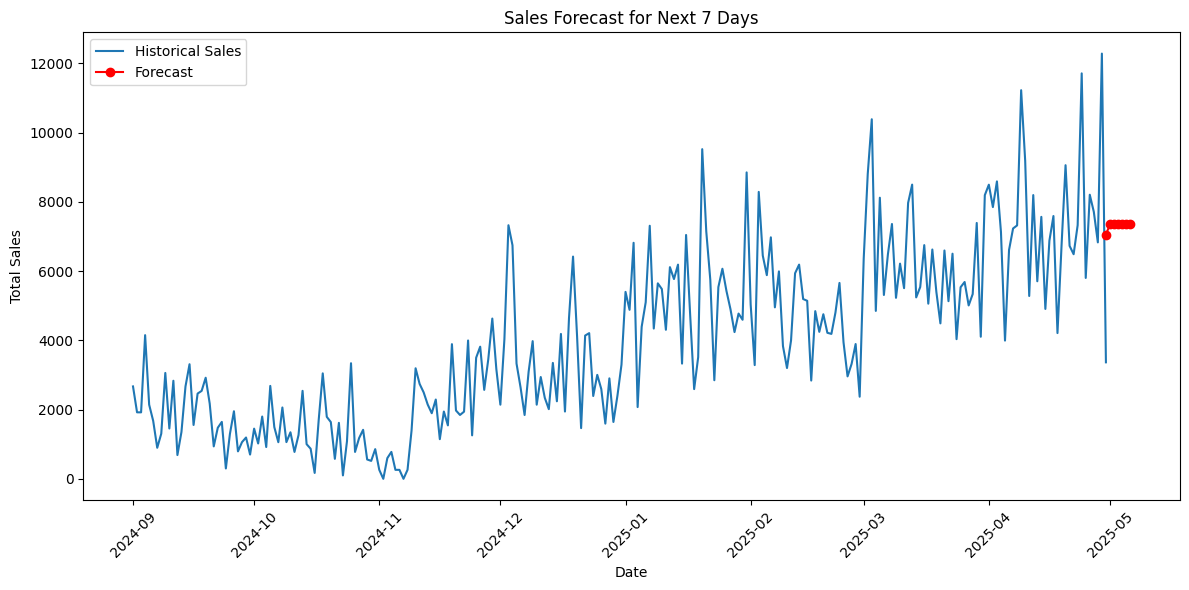


🔍 Additional Metrics:
Average ROAS: 1.96
Average ACOS: 76.17%
Average TACOS: 28.96%
Ad Conversion Rate: 7.20%
❌ Error saving forecast: [Errno 13] Permission denied: 'C:/Users/HEMAL/Downloads/Kitoko Data/Kitoko order details.xlsx'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# File path
file_path = r'C:/Users/HEMAL/Downloads/Kitoko Data/Kitoko order details.xlsx'

# Load Sales Data sheet
try:
    sales_df = pd.read_excel(file_path, sheet_name='Sales Data')
    print("✅ Sales Data loaded successfully")
except Exception as e:
    print(f"❌ Error loading Sales Data sheet: {e}")
    exit()

# Preview
print(sales_df.head())

# Step 1: Preprocess the date column
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d-%m-%Y', errors='coerce')
sales_df = sales_df.sort_values('Date')

# Step 2: Convert numeric columns (remove commas, if any)
numeric_cols = sales_df.columns.drop('Date')
for col in numeric_cols:
    sales_df[col] = pd.to_numeric(sales_df[col], errors='coerce')

# Drop rows with missing Total Sales
sales_df = sales_df.dropna(subset=['Total Sales'])

# Step 3: Plot Total Sales over time
plt.figure(figsize=(12,6))
plt.plot(sales_df['Date'], sales_df['Total Sales'], marker='o')
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 4: Build ARIMA model (simple baseline)
sales_series = sales_df.set_index('Date')['Total Sales']

# Check for sufficient data points (ARIMA needs ~30+ ideally)
if len(sales_series) < 30:
    print("⚠️ Warning: ARIMA usually needs more data points, results may be rough.")

# Fit ARIMA(1,1,1) as a quick baseline (can tune later)
model = ARIMA(sales_series, order=(1,1,1))
model_fit = model.fit()

# Forecast next 7 days
forecast = model_fit.forecast(steps=7)
print("📈 Next 7 days forecast:")
print(forecast)

# Plot forecast
plt.figure(figsize=(12,6))
plt.plot(sales_series, label='Historical Sales')
plt.plot(pd.date_range(sales_series.index[-1], periods=7, freq='D'), forecast, label='Forecast', color='red', marker='o')
plt.title('Sales Forecast for Next 7 Days')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 5: Additional Metrics
avg_roas = sales_df['ROAS'].mean()
avg_acos = sales_df['ACOS'].mean()
avg_tacos = sales_df['TACOS'].mean()
conversion_rate = (sales_df['Ad Orders'].sum() / sales_df['Clicks'].sum()) * 100

print(f"\n🔍 Additional Metrics:")
print(f"Average ROAS: {avg_roas:.2f}")
print(f"Average ACOS: {avg_acos:.2f}%")
print(f"Average TACOS: {avg_tacos:.2f}%")
print(f"Ad Conversion Rate: {conversion_rate:.2f}%")

# Save forecasts and metrics to Excel (new sheet)
output_df = pd.DataFrame({
    'Date': pd.date_range(sales_series.index[-1], periods=7, freq='D'),
    'Forecasted Sales': forecast
})

metrics_df = pd.DataFrame({
    'Metric': ['Average ROAS', 'Average ACOS', 'Average TACOS', 'Ad Conversion Rate'],
    'Value': [avg_roas, avg_acos, avg_tacos, conversion_rate]
})

from openpyxl import load_workbook

try:
    book = load_workbook(file_path)
    with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
        if 'Sales_Forecast' in book.sheetnames:
            std = book['Sales_Forecast']
            book.remove(std)
            book.save(file_path)
        output_df.to_excel(writer, sheet_name='Sales_Forecast', index=False)
        metrics_df.to_excel(writer, sheet_name='Sales_Forecast', index=False, startrow=10)
    print(f"✅ Forecast and metrics saved to 'Sales_Forecast' sheet")
except Exception as e:
    print(f"❌ Error saving forecast: {e}")
